# 15.2 — Tear-sheet gallery (fully offline)

The metrics companion to `15_equity_gallery.ipynb`: one collective tear sheet
for every persisted portfolio line, evaluated on a single common window (the
intersection of the lines' active spans, each line re-based at the window
start), then a three-way comparison of static buy & hold, the SJM×crowding
de-risk overlay, and the best macro-factor line without SJM.

Everything is read from local parquet files — **no network, no LLM, no
credentials**. Conventions mirror `scripts/build_tear_sheet.py` and the
published `data/tear_sheet/tear_sheet.csv` exactly:

- active-span trim: the flat pre-start stub of 2014-anchored frames is dropped;
- vectorbt 365-day calendar basis: CAGR `(1+TR)^(365/n)-1`, Sharpe/vol on
  `sqrt(365)`, empyrical downside RMS for Sortino, day-0 return = 0;
- SSR (Sharpe Stability Ratio, Newey-West HAC, Andrews bandwidth) is the
  honesty instrument;
- the benchmark and factor blocks regress on SPY and the portfolio's own 4-ETF
  basket (`SWDA.L/XLK/IAU/BIL`) from the offline price cache
  `data/etf_prices_wide_2013_2026.parquet` (the nb17 artifact).

> **Price-source caveat**: the offline cache carries price-only (unadjusted)
> series, so dividends are missing. Beta, correlation, R², tracking error and
> idio vol are essentially unaffected. Active return vs SPY reads about
> 1.3–1.8 pp/yr higher than against a dividend-adjusted benchmark, because
> SPY's full yield is missing from its price-only CAGR. Regression α shifts
> only by β × yield: about +1 pp/yr at β≈0.6, 0.2–0.45 pp/yr for the low-β
> factor lines, and the sign can flip with the regression fit (measured vs the
> published `risk_decomposition.csv`: +0.99 pp at β 0.60, −0.50 pp at β 0.22).
> Cross-line comparisons are unaffected because every line faces the same
> benchmark. Line register and provenance: `workbook/SIMULATIONS.md`.

Standing framing: these are **realized simulation equity curves only** — no
forecast-accuracy claims are made or implied.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "workbook"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from factor_workbook.rederive import equity_metrics
from macro_framework.ssr import compute_ssr

pd.set_option("display.width", 260)
pd.set_option("display.max_columns", 40)

DATA = REPO / "data"
ANNUAL = 365                      # vectorbt calendar-year basis (repo convention)
BASKET = ["SWDA.L", "XLK", "IAU", "BIL"]
BENCH = "SPY"

# (file stem, short label, is_diagnostic) — same register as 15_equity_gallery
LINES = [
    ("static_bh_equity_2016_2026", "Static B&H 16-26", False),
    ("static_bh_equity_2014_2024", "Static B&H 14-24", False),
    ("factor_equity_v1", "Factor v1", False),
    ("factor_equity_v2", "Factor v2", False),
    ("factor_nonpit_diagnostic_equity_v1", "Factor non-PIT v1", True),
    ("factor_equity_ext2026", "Factor ext26", False),
    ("factor_nonpit_diagnostic_equity_ext2026", "Factor non-PIT ext26", True),
    ("baseline_equity_2019_2024", "Baseline 19-24", False),
    ("track_a_equity_2019_2024", "Track A 19-24", False),
    ("track_a_steered_equity_2019_2024", "Track A steered", False),
    ("track_b_equity_2019_2024", "Track B 19-24", False),
    ("baseline_equity_ext2026", "Baseline ext26", False),
    ("track_b_equity_ext2026", "Track B ext26", False),
    ("sjm_crowding_derisk_equity_ext2026", "SJM×crowding de-risk ext26", False),
]


def active_value(value: pd.Series) -> pd.Series:
    """Trim to the active span: last flat day before the first move onward.

    Same convention as ``scripts/build_tear_sheet.py`` — drops the flat
    pre-start stub of lines stored on the 2014-anchored frame.
    """
    moving = value[value.ne(value.iloc[0])]
    if moving.empty:
        return value
    first_move = moving.index.min()
    prior = value.index[value.index < first_move]
    start = prior.max() if len(prior) else first_move
    return value.loc[start:]


loaded: dict[str, tuple[str, bool, pd.Series]] = {}
for stem, label, diag in LINES:
    path = DATA / f"{stem}.parquet"
    if not path.exists():
        print(f"SKIPPED (not present locally): {path.name}")
        continue
    loaded[stem] = (label, diag, active_value(pd.read_parquet(path)["value"]))

# offline price cache (nb17 artifact): SPY benchmark + the 4-ETF basket factors
PX_CACHE = DATA / "etf_prices_wide_2013_2026.parquet"
if PX_CACHE.exists():
    _px = pd.read_parquet(PX_CACHE)
    spy_px = _px[BENCH].dropna()
    basket_ret = _px[BASKET].pct_change()
    print(f"price cache: {PX_CACHE.name}  "
          f"{_px.index.min():%Y-%m-%d} → {_px.index.max():%Y-%m-%d}")
else:
    spy_px, basket_ret = None, None
    print(f"SKIPPED benchmark/factor blocks (missing {PX_CACHE.name})")
print(f"{len(loaded)}/{len(LINES)} lines loaded")

price cache: etf_prices_wide_2013_2026.parquet  2013-01-02 → 2026-05-29
14/14 lines loaded


In [2]:
def tear_sheet_row(value: pd.Series, label: str) -> dict:
    """Full tear-sheet row for one (already window-sliced) equity value line.

    Return/risk metrics mirror ``scripts/build_tear_sheet.py`` (vbt 365-day
    basis, day-0 zero return); the benchmark/factor blocks regress on the
    offline price cache (price-only SPY — see the caveat above).
    """
    m = equity_metrics(value)
    r = value.pct_change().dropna()
    r0 = value.pct_change().fillna(0.0)               # day-0 zero, vbt convention
    downside = np.minimum(r0.to_numpy(dtype=float), 0.0)

    dd = value / value.cummax() - 1
    dd_trough = dd.idxmin()
    dd_peak = value.loc[:dd_trough].idxmax()
    rec = dd.loc[dd_trough:][dd.loc[dd_trough:] >= -1e-12]
    ssr = compute_ssr(r)

    row = {
        "Label": label,
        "Start": r.index.min().date(), "End": r.index.max().date(),
        "Number of days": len(r),
        "Total Return": m.total_return, "CAGR": m.annualized_return,
        "Ann. Volatility": m.annualized_vol, "Sharpe": m.sharpe,
        "Downside vol (daily)": float(np.sqrt(np.mean(downside ** 2))),
        "Sortino": m.sortino, "Max Drawdown": m.max_drawdown, "Calmar": m.calmar,
        "VaR 95 (daily)": float(r.quantile(0.05)),
        "CVaR 95 (daily)": float(r[r <= r.quantile(0.05)].mean()),
        "Skew": float(r.skew()), "Excess Kurtosis": float(r.kurtosis()),
        "Hit Rate": float((r > 0).mean()),
        "SSR (Sharpe Stability Ratio)": ssr.ssr,
        "SSR verdict": ("n/a (window too short)" if not np.isfinite(ssr.ssr)
                        else "stably > 0" if abs(ssr.ssr) >= 1.96
                        else "NOT distinguishable from zero under HAC — luck-compatible"),
        "Max Drawdown Peak": dd_peak.date(), "Max Drawdown Trough": dd_trough.date(),
        "Max Drawdown Recovered": rec.index.min().date() if len(rec) else None,
    }
    if spy_px is None:
        return row

    spy_r = spy_px.pct_change().reindex(r.index).dropna()
    y = r.reindex(spy_r.index)
    x = np.column_stack([np.ones(len(spy_r)), spy_r.to_numpy()])
    coef, *_ = np.linalg.lstsq(x, y.to_numpy(), rcond=None)
    resid = y - x @ coef
    r2 = 1.0 - float((resid ** 2).sum()) / float(((y - y.mean()) ** 2).sum())
    idio = float(resid.std(ddof=1) * np.sqrt(ANNUAL))
    alpha_ann = float(coef[0] * ANNUAL)

    # SPY line resampled onto the portfolio's own dates -> same 365/n basis
    spy_v = spy_px.reindex(value.index).ffill().dropna()
    cagr_spy = float((spy_v.iloc[-1] / spy_v.iloc[0]) ** (ANNUAL / len(spy_v)) - 1)
    te = float((y - spy_r).std(ddof=1) * np.sqrt(ANNUAL))
    active = m.annualized_return - cagr_spy

    row.update({
        "Correlation to S&P 500": float(y.corr(spy_r)),
        "Beta": float(coef[1]),
        "Active Return (ann.)": active,
        "Tracking Error (ann.)": te,
        "Information Ratio": active / te if te > 0 else np.nan,
        "R² (CAPM, 1-factor)": r2,
        "Idio vol σε (ann., CAPM)": idio,
        "α (regression, ann.)": alpha_ann,
        "Appraisal Ratio (α/σε)": alpha_ann / idio if idio > 0 else np.nan,
    })

    b = basket_ret.reindex(r.index).dropna()
    yb = r.reindex(b.index)
    xb = np.column_stack([np.ones(len(b)), b.to_numpy()])
    coefb, *_ = np.linalg.lstsq(xb, yb.to_numpy(), rcond=None)
    residb = yb - xb @ coefb
    r2b = 1.0 - float((residb ** 2).sum()) / float(((yb - yb.mean()) ** 2).sum())
    row.update({
        "R² (4-ETF basket)": r2b,
        "Residual vol basket (ann.)": float(residb.std(ddof=1) * np.sqrt(ANNUAL)),
        "Model note (REF)": "basket R²≈1 → residual is allocation-timing, not stock-picking",
    })
    return row


SECTIONS = [
    ("Window", ["Label", "Start", "End", "Number of days"]),
    ("Return vs. Risk", ["Total Return", "CAGR", "Ann. Volatility", "Sharpe",
                         "Downside vol (daily)", "Sortino", "Max Drawdown", "Calmar",
                         "VaR 95 (daily)", "CVaR 95 (daily)", "Skew",
                         "Excess Kurtosis", "Hit Rate"]),
    ("Benchmark vs. S&P 500", ["Correlation to S&P 500", "Beta", "Active Return (ann.)",
                               "Tracking Error (ann.)", "Information Ratio"]),
    ("Factor risk and performance", ["R² (CAPM, 1-factor)", "Idio vol σε (ann., CAPM)",
                                     "α (regression, ann.)", "Appraisal Ratio (α/σε)",
                                     "R² (4-ETF basket)", "Residual vol basket (ann.)",
                                     "Model note (REF)"]),
    ("Stability (the honesty instrument)", ["SSR (Sharpe Stability Ratio)", "SSR verdict"]),
    ("Max drawdown detail", ["Max Drawdown Peak", "Max Drawdown Trough",
                             "Max Drawdown Recovered"]),
]
ORDER = [metric for _, metrics in SECTIONS for metric in metrics]
PCT = {"Total Return", "CAGR", "Ann. Volatility", "Downside vol (daily)", "Max Drawdown",
       "VaR 95 (daily)", "CVaR 95 (daily)", "Hit Rate", "Active Return (ann.)",
       "Tracking Error (ann.)", "Idio vol σε (ann., CAPM)", "α (regression, ann.)",
       "Residual vol basket (ann.)"}
RATIO = {"Sharpe", "Sortino", "Calmar", "Skew", "Excess Kurtosis", "Correlation to S&P 500",
         "Beta", "Information Ratio", "R² (CAPM, 1-factor)", "Appraisal Ratio (α/σε)",
         "R² (4-ETF basket)", "SSR (Sharpe Stability Ratio)"}


def render(rows: dict[str, dict]) -> pd.DataFrame:
    """rows {column label -> tear_sheet_row dict} -> formatted sectioned sheet."""
    raw = pd.DataFrame(rows).reindex(ORDER)

    def fmt(val, metric):
        if val is None or (isinstance(val, float) and pd.isna(val)):
            return ""
        if metric in PCT:
            return f"{val * 100:,.1f}%"
        if metric in RATIO:
            return f"{val:,.2f}"
        return str(val)

    out = pd.DataFrame({c: [fmt(raw.loc[metric, c], metric) for metric in ORDER]
                        for c in raw.columns}, index=ORDER)
    out.index = pd.MultiIndex.from_tuples(
        [(sec, metric) for sec, metrics in SECTIONS for metric in metrics])
    return out

In [3]:
# Engine self-check: same code path as scripts/build_tear_sheet.py, so the full
# active span of the static B&H line must reproduce the published tear sheet.
ts_csv = DATA / "tear_sheet" / "tear_sheet.csv"
if ts_csv.exists() and "static_bh_equity_2016_2026" in loaded:
    pub = pd.read_csv(ts_csv).set_index("line").loc["static_bh_2016_2026"]
    mine = tear_sheet_row(loaded["static_bh_equity_2016_2026"][2], "check")
    checks = [("Total Return", "total_return"), ("CAGR", "cagr"),
              ("Ann. Volatility", "ann_vol"), ("Sharpe", "sharpe"),
              ("Sortino", "sortino"), ("Max Drawdown", "max_drawdown"),
              ("Calmar", "calmar"), ("VaR 95 (daily)", "var_95_daily"),
              ("CVaR 95 (daily)", "cvar_95_daily"), ("Skew", "skew"),
              ("Excess Kurtosis", "excess_kurtosis"), ("Hit Rate", "positive_day_rate"),
              ("SSR (Sharpe Stability Ratio)", "ssr")]
    for ours, theirs in checks:
        assert abs(mine[ours] - float(pub[theirs])) < 1e-6, (ours, mine[ours], pub[theirs])
    assert mine["Number of days"] == int(pub["n_days"])
    print(f"engine check vs published tear_sheet.csv: PASS "
          f"({len(checks)} metrics, |Δ| < 1e-6, n_days == {int(pub['n_days'])})")

    rd_csv = DATA / "tear_sheet" / "risk_decomposition.csv"
    if rd_csv.exists() and spy_px is not None:
        rd = pd.read_csv(rd_csv).set_index("line").loc["static_bh_2016_2026"]
        print("benchmark block — offline cache vs published (yfinance adjusted close):")
        print(f"  beta {mine['Beta']:+.3f} vs {rd['beta_spy']:+.3f}   "
              f"corr {mine['Correlation to S&P 500']:.3f} vs {rd['corr_spy']:.3f}   "
              f"R² {mine['R² (CAPM, 1-factor)']:.3f} vs {rd['r2_capm']:.3f}   "
              f"α {mine['α (regression, ann.)']:.1%} vs {rd['alpha_ann_vs_spy']:.1%}")
        print("  (α gap ≈ β × SPY dividend yield, ≈ +1.0 pp at β 0.60; "
              "beta/corr/R² match — caveat in the header)")
else:
    print("published tear_sheet.csv not present — self-check skipped")

engine check vs published tear_sheet.csv: PASS (13 metrics, |Δ| < 1e-6, n_days == 2468)
benchmark block — offline cache vs published (yfinance adjusted close):
  beta +0.602 vs +0.605   corr 0.837 vs 0.838   R² 0.701 vs 0.702   α 10.7% vs 9.7%
  (α gap ≈ β × SPY dividend yield, ≈ +1.0 pp at β 0.60; beta/corr/R² match — caveat in the header)


## Collective tear sheet — one common window for every line

The window below is the intersection of all active spans (roughly the
2019→2024 stream). Every line is sliced to it and re-based at the window
start, so the columns are directly comparable, unlike the per-line windows of
the published `tear_sheet.csv`. Non-PIT columns are tagged **[DIAG]** —
diagnostic controls, never deployable. On this window the two [DIAG] columns
coincide: `_ext2026` is the same non-PIT stream extended into 2025–26 and the
extension lies entirely beyond the window end, so the pair is one series shown
twice (kept for register completeness). Raw numbers are mirrored to
`data/tear_sheet/tear_sheet_gallery_common_window.csv` (gitignored pack, like
the other tear-sheet CSVs).

In [4]:
COMMON_START = max(v.index.min() for _, _, v in loaded.values())
COMMON_END = min(v.index.max() for _, _, v in loaded.values())
print(f"common window: {COMMON_START:%Y-%m-%d} → {COMMON_END:%Y-%m-%d}")

rows = {}
for stem, (label, diag, v) in loaded.items():
    col = label + ("  [DIAG]" if diag else "")
    rows[col] = tear_sheet_row(v.loc[COMMON_START:COMMON_END], label)

sheet = render(rows)
raw = pd.DataFrame(rows).reindex(ORDER)
outdir = DATA / "tear_sheet"
outdir.mkdir(exist_ok=True)
raw.T.to_csv(outdir / "tear_sheet_gallery_common_window.csv")
sheet

common window: 2019-01-02 → 2024-12-30


Static B&H 16-26                                   Static B&H 14-24                                          Factor v1  \
Window                             Label                                                          Static B&H 16-26                                   Static B&H 14-24                                          Factor v1   
                                   Start                                                                2019-01-03                                         2019-01-03                                         2019-01-03   
                                   End                                                                  2024-12-30                                         2024-12-30                                         2024-12-30   
                                   Number of days                                                             1478                                               1478                                               1478   
Return vs. Risk                    Total Return                                                             149.8%                                             158.6%                                              82.2%   
                                   CAGR                                                                      25.3%                                              26.4%                                              16.0%   
                                   Ann. Volatility                                                           16.8%                                              17.9%                                               9.7%   
                                   Sharpe                                                                     1.43                                               1.40                                               1.57   
                                   Downside vol (daily)                                                       0.6%                                               0.7%                                               0.3%   
                                   Sortino                                                                    2.05                                               2.00                                               2.32   
                                   Max Drawdown                                                             -19.6%                                             -20.7%                                             -11.4%   
                                   Calmar                                                                     1.29                                               1.28                                               1.40   
                                   VaR 95 (daily)                                                            -1.3%                                              -1.4%                                              -0.7%   
                                   CVaR 95 (daily)                                                           -2.0%                                              -2.2%                                              -1.1%   
                                   Skew                                                                      -0.34                                              -0.35                                              -0.07   
                                   Excess Kurtosis                                                            5.54                                               5.53                                               8.27   
                                   Hit Rate                                                                  56.2%                                              56.1%                                              56.0%   
Benchmark vs. S&P 500              Correlation to S&P 500                                                     0.90                        

In [5]:
# quick ranking on the common window (headline metrics only)
rank_cols = ["Sharpe", "Calmar", "CAGR", "Max Drawdown", "SSR (Sharpe Stability Ratio)"]
rank = raw.loc[rank_cols].T.astype(float).sort_values("Sharpe", ascending=False)
rank.round(3)

,Sharpe,Calmar,CAGR,Max Drawdown,SSR (Sharpe Stability Ratio)
SJM×crowding de-risk ext26,1.730,1.490,0.122,-0.082,0.120
Track A steered,1.684,1.575,0.205,-0.130,0.127
Factor ext26,1.626,1.378,0.166,-0.121,0.123
Factor non-PIT v1 [DIAG],1.624,1.528,0.171,-0.112,0.130
Factor non-PIT ext26 [DIAG],1.624,1.528,0.171,-0.112,0.130
Factor v2,1.623,1.273,0.159,-0.125,0.111
Track A 19-24,1.596,1.472,0.192,-0.131,0.125
Factor v1,1.572,1.399,0.160,-0.114,0.125
Static B&H 16-26,1.431,1.291,0.253,-0.196,0.133
Static B&H 14-24,1.399,1.278,0.264,-0.207,0.133


## Final comparison — static B&H vs SJM de-risk vs best macro-factor (no SJM)

Selection rule for the third seat: among the PIT macro-factor lines
(`factor_equity_v1`, `factor_equity_v2`, `factor_equity_ext2026` — no SJM
overlay; non-PIT diagnostics excluded, they are never-deployable controls),
take the best Sharpe on the collective common window above. The trio is then
re-evaluated on its own common window, which runs longer than the all-lines
window because all three lines reach into 2026.

In [6]:
FACTOR_CANDIDATES = ["factor_equity_v1", "factor_equity_v2", "factor_equity_ext2026"]
cand = {s: rows[loaded[s][0]]["Sharpe"] for s in FACTOR_CANDIDATES if s in loaded}
best_stem = max(cand, key=cand.get)
print("macro-factor candidates, Sharpe on the common window:")
for s, sh in sorted(cand.items(), key=lambda kv: -kv[1]):
    print(f"  {'→' if s == best_stem else ' '} {loaded[s][0]:<14s} ({s}): {sh:.3f}")

TRIO = ["static_bh_equity_2016_2026", best_stem, "sjm_crowding_derisk_equity_ext2026"]
trio_vals = {loaded[s][0]: loaded[s][2] for s in TRIO}
t_start = max(v.index.min() for v in trio_vals.values())
t_end = min(v.index.max() for v in trio_vals.values())
print(f"\ntrio common window: {t_start:%Y-%m-%d} → {t_end:%Y-%m-%d}")

trio_rows = {lbl: tear_sheet_row(v.loc[t_start:t_end], lbl) for lbl, v in trio_vals.items()}
render(trio_rows)

macro-factor candidates, Sharpe on the common window:
  → Factor ext26   (factor_equity_ext2026): 1.626
    Factor v2      (factor_equity_v2): 1.623
    Factor v1      (factor_equity_v1): 1.572

trio common window: 2019-01-02 → 2026-01-30


Static B&H 16-26                                       Factor ext26                         SJM×crowding de-risk ext26
Window                             Label                                                          Static B&H 16-26                                       Factor ext26                         SJM×crowding de-risk ext26
                                   Start                                                                2019-01-03                                         2019-01-03                                         2019-01-03
                                   End                                                                  2026-01-30                                         2026-01-30                                         2026-01-30
                                   Number of days                                                             1745                                               1745                                               1745
Return vs. Risk                    Total Return                                                             224.3%                                             148.8%                                              99.2%
                                   CAGR                                                                      27.9%                                              21.0%                                              15.5%
                                   Ann. Volatility                                                           17.6%                                              11.1%                                               8.0%
                                   Sharpe                                                                     1.48                                               1.78                                               1.83
                                   Downside vol (daily)                                                       0.6%                                               0.4%                                               0.3%
                                   Sortino                                                                    2.14                                               2.60                                               2.69
                                   Max Drawdown                                                             -19.6%                                             -12.1%                                              -8.2%
                                   Calmar                                                                     1.42                                               1.74                                               1.90
                                   VaR 95 (daily)                                                            -1.3%                                              -0.8%                                              -0.6%
                                   CVaR 95 (daily)                                                           -2.1%                                              -1.3%                                              -0.9%
                                   Skew                                                                      -0.11                                              -0.48                                              -0.58
                                   Excess Kurtosis                                                            9.60                                              24.25                                              31.23
                                   Hit Rate                                                                  56.7%                                              57.0%                                              56.9%
Benchmark vs. S&P 500              Correlation to S&P 500                                                     0.85                                               0.49                           

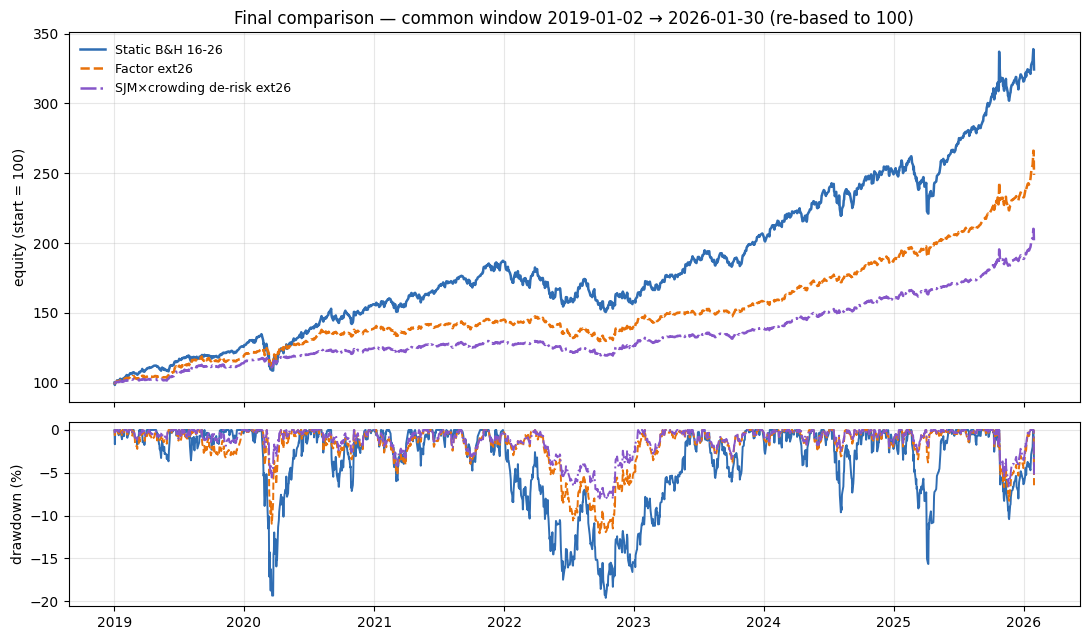

In [7]:
# Palette validated for color-vision deficiency (blue/orange/purple), with a
# distinct linestyle per series so the lines can be told apart without color.
STYLE = dict(zip(trio_vals, [("#2f6db3", "-"), ("#e8710a", "--"), ("#8656c9", "-.")]))

fig, (ax_eq, ax_dd) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
for lbl, v in trio_vals.items():
    w = v.loc[t_start:t_end]
    color, ls = STYLE[lbl]
    ax_eq.plot(w.index, 100 * w / w.iloc[0], lw=1.8, color=color, ls=ls, label=lbl)
    dd = w / w.cummax() - 1
    ax_dd.plot(dd.index, 100 * dd, lw=1.4, color=color, ls=ls)
ax_eq.set_title(f"Final comparison — common window {t_start:%Y-%m-%d} → {t_end:%Y-%m-%d} "
                f"(re-based to 100)")
ax_eq.set_ylabel("equity (start = 100)")
ax_eq.grid(alpha=0.3)
ax_eq.legend(frameon=False, fontsize=9)
ax_dd.set_ylabel("drawdown (%)")
ax_dd.grid(alpha=0.3)
fig.tight_layout()
plt.show()

---

Realized simulation curves only — no forecast-accuracy claims. The SSR row is
the honesty instrument: a Sharpe whose SSR is not distinguishable from zero
under HAC is luck-compatible, whatever its point estimate. Benchmark-relative
rows inherit the price-only SPY caveat from the header. Per-run provenance:
`workbook/SIMULATIONS.md`; Excel path: `workbook/ASSESSMENT.md`.